# 🌍 Hackathon IndabaX Cameroon 2026
## Starter Notebook - Français
### *L'IA au service de la résilience climatique et sanitaire*

# 01 - Compréhension des données et construction de la cible VRI

## Objectif
Dans ce notebook, nous allons :

1. Charger et explorer les données météorologiques
2. Nettoyer les colonnes essentielles
3. Construire une cible **VRI** (Indice de Risque Vectoriel Météorologique)
4. Vérifier que cette cible est cohérente dans le temps et selon les villes
5. Sauvegarder un dataset enrichi pour la modélisation

## Contexte
Le projet s’inscrit dans le cadre du Hackathon **IndabaX Cameroon 2026** sur le thème :

**L’IA au service de la résilience climatique et sanitaire au Cameroun**

Le VRI est ici défini comme un **proxy météorologique** du risque vectoriel, construit à partir de la température, de l’humidité et des précipitations.

## 1. Setup & Chargement

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Imports OK')

Imports OK


---
## 1. Chargement et nettoyage des types

---
## 2. Chargement des donnees

In [59]:
df = pd.read_excel('../data/Dataset_complet_Meteo.xlsx')
df.head()

,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,2026-09-21 00:00:00,2026-05-26 00:00:00,34.0,2026-06-25 00:00:00,2026-01-29 00:00:00,2020-01-01 06:22:00,...,0.0,2026-05-10 00:00:00,2026-05-24 00:00:00,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,2026-09-21 00:00:00,2026-09-25 00:00:00,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,2026-05-08 00:00:00,2026-06-25 00:00:00,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,2026-03-19 00:00:00,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,2026-01-25 00:00:00,2020-01-03 06:23:00,...,0.0,2026-09-08 00:00:00,2026-09-25 00:00:00,65,2026-03-20 00:00:00,4.78,Bafia,Centre,4.75,11.23
3,4,2020-01-04,3,2026-05-31 00:00:00,2026-01-19 00:00:00,2026-07-24 00:00:00,32.3,2026-07-20 00:00:00,2026-04-25 00:00:00,2020-01-04 06:24:00,...,0.0,2026-02-11 00:00:00,2026-02-20 00:00:00,106,20.48,4.59,Bafia,Centre,4.75,11.23
4,5,2020-01-05,3,31.9,2026-03-19 00:00:00,2026-08-24 00:00:00,33.1,2026-03-20 00:00:00,2026-09-25 00:00:00,2020-01-05 06:24:00,...,0.0,2026-03-11 00:00:00,2026-08-23 00:00:00,100,19.98,4.39,Bafia,Centre,4.75,11.23


In [60]:
# Affichage des dimensions du dataset
print("Dimensions du dataset :", df.shape)


Dimensions du dataset : (87240, 26)


In [61]:
# Affichage des colonnes et des types de données
print("\nColonnes et types de données :")
print(df.dtypes)


Colonnes et types de données :
id                                      int64
time                           datetime64[ns]
weather_code                            int64
temperature_2m_max                     object
temperature_2m_min                     object
temperature_2m_mean                    object
apparent_temperature_max               object
apparent_temperature_min               object
apparent_temperature_mean              object
sunrise                        datetime64[ns]
sunset                         datetime64[ns]
daylight_duration                     float64
sunshine_duration                      object
precipitation_sum                      object
rain_sum                               object
snowfall_sum                          float64
precipitation_hours                   float64
wind_speed_10m_max                     object
wind_gusts_10m_max                     object
wind_direction_10m_dominant             int64
shortwave_radiation_sum                object
et

In [62]:
df.isna().sum()

id                             0
time                           0
weather_code                   0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
apparent_temperature_max       0
apparent_temperature_min       0
apparent_temperature_mean      0
sunrise                        0
sunset                         0
daylight_duration              0
sunshine_duration              0
precipitation_sum              0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
et0_fao_evapotranspiration     0
city                           0
region                         0
latitude                       0
longitude                      0
dtype: int64

In [63]:
# Conversion de la colonne 'time' en datetime et tri chronologique
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(by='time')

In [64]:
# ── Vérification de la continuité temporelle (trous de dates) ─────────────────
df_sorted = df_clean.sort_values(by='time')
df_sorted['time_diff'] = df_sorted.groupby('city')['time'].diff().dt.days
gaps = df_sorted[df_sorted['time_diff'] > 1]
if not gaps.empty:
    print("⚠️ Trous de dates détectés :")
    print(gaps[['city', 'time', 'time_diff']])
else:
    print('Aucun trou de dates détecté.')

Aucun trou de dates détecté.


In [65]:
# conversion des colonnes numériques (stockées en string dans le fichier)
num_cols = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'sunshine_duration', 'latitude', 'longitude','apparent_temperature_min',
    'apparent_temperature_max'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Dataset : {df.shape[0]:,} obs × {df.shape[1]} variables")
print(f"   Période  : {df['time'].min().date()} → {df['time'].max().date()}")
print(f"   Villes   : {df['city'].nunique()} | Régions : {df['region'].nunique()}")
df.info()


Dataset : 87,240 obs × 26 variables
   Période  : 2020-01-01 → 2025-12-20
   Villes   : 40 | Régions : 10
<class 'pandas.core.frame.DataFrame'>
Index: 87240 entries, 0 to 87239
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           87240 non-null  int64         
 1   time                         87240 non-null  datetime64[ns]
 2   weather_code                 87240 non-null  int64         
 3   temperature_2m_max           33334 non-null  float64       
 4   temperature_2m_min           12005 non-null  float64       
 5   temperature_2m_mean          11508 non-null  float64       
 6   apparent_temperature_max     56344 non-null  float64       
 7   apparent_temperature_min     9568 non-null   float64       
 8   apparent_temperature_mean    17677 non-null  float64       
 9   sunrise                      87240 non-null  datetime64[ns]
 10  sunse

In [66]:
# verification des doublons
n_dup = df.duplicated(subset=['city','time']).sum()
print(f'Nombre de doublons city+time : {n_dup}')

Nombre de doublons city+time : 0


In [67]:
# verification des variables manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df.isna().sum())


Nombre de valeurs manquantes par colonne :
id                                 0
time                               0
weather_code                       0
temperature_2m_max             53906
temperature_2m_min             75235
temperature_2m_mean            75732
apparent_temperature_max       30896
apparent_temperature_min       77672
apparent_temperature_mean      69563
sunrise                            0
sunset                             0
daylight_duration                  0
sunshine_duration                489
precipitation_sum              39471
rain_sum                       39471
snowfall_sum                       0
precipitation_hours                0
wind_speed_10m_max             77862
wind_gusts_10m_max             45573
wind_direction_10m_dominant        0
shortwave_radiation_sum        17342
et0_fao_evapotranspiration     17119
city                               0
region                             0
latitude                       13086
longitude                      

In [68]:
# Gestion des valeurs manquantes
# 🔴 CRITIQUES VRI (>60k manquants) - Forward Fill prioritaire
critical_vars = ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
                'apparent_temperature_mean', 'precipitation_sum', 'rain_sum']

# 🟡 IMPORTANTES VRI - Interpolation
important_vars = ['apparent_temperature_max', 'apparent_temperature_min',
                 'wind_speed_10m_max', 'wind_gusts_10m_max', 'et0_fao_evapotranspiration']

# 🟢 Secondaires - Rolling mean
secondary_vars = ['sunshine_duration', 'shortwave_radiation_sum']

# 2. FONCTION FIXÉE ✅ (APPLY + LAMBDA)
def fill_time_series_adaptive(df, group_cols=['city', 'region']):
    df_filled = df.copy()
    
    # Priorités VRI
    critical_vars = ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
                    'precipitation_sum', 'rain_sum']
    important_vars = ['apparent_temperature_mean', 'et0_fao_evapotranspiration',
                     'wind_speed_10m_max', 'wind_gusts_10m_max']
    secondary_vars = ['sunshine_duration', 'shortwave_radiation_sum']
    
    # === PHASE 1 : CRITIQUES VRI (Forward Fill) ===
    print("🔴 CRITIQUES VRI...")
    for col in critical_vars:
        if col in df.columns:
            df_filled[col] = df_filled.groupby(group_cols)[col].ffill().bfill()
            print(f"  {col}: {df[col].isnull().sum():,} → {df_filled[col].isnull().sum():,}")
    
    # === PHASE 2 : IMPORTANTES (INTERPOLATION FIXÉE) ===
    print("\n🟡 IMPORTANTES VRI...")
    for col in important_vars:
        if col in df.columns:
            # ✅ FIX: apply(lambda x: x.interpolate())
            df_filled[col] = df_filled.groupby(group_cols)[col].apply(
                lambda x: x.interpolate(method='linear').ffill().bfill()
            ).reset_index(level=group_cols, drop=True)
            print(f"  {col}: {df[col].isnull().sum():,} → {df_filled[col].isnull().sum():,}")
    
    # === PHASE 3 : SECOND AIRES (Rolling) ===
    print("\n🟢 SECOND AIRES...")
    for col in secondary_vars:
        if col in df.columns:
            df_filled[col] = df_filled.groupby(group_cols)[col].apply(
                lambda x: x.rolling(14, min_periods=5, center=True).mean().ffill().bfill()
            ).reset_index(level=group_cols, drop=True)
            print(f"  {col}: {df[col].isnull().sum():,} → {df_filled[col].isnull().sum():,}")
    
    # === PHASE 4 : GEOLOC ===
    print("\n📍 GEOLOC...")
    for col in ['latitude', 'longitude']:
        if col in df.columns:
            df_filled[col] = df_filled.groupby('region')[col].transform(lambda x: x.fillna(x.median()))
            print(f"  {col}: {df[col].isnull().sum():,} → {df_filled[col].isnull().sum():,}")
    
    return df_filled

# EXECUTION ✅
df_clean = fill_time_series_adaptive(df)
print(f"\n✅ Dataset propre: {df_clean.shape}")

🔴 CRITIQUES VRI...
  temperature_2m_mean: 75,732 → 0
  temperature_2m_max: 53,906 → 0
  temperature_2m_min: 75,235 → 0
  precipitation_sum: 39,471 → 0
  rain_sum: 39,471 → 0

🟡 IMPORTANTES VRI...
  apparent_temperature_mean: 69,563 → 0
  et0_fao_evapotranspiration: 17,119 → 0
  wind_speed_10m_max: 77,862 → 0
  wind_gusts_10m_max: 45,573 → 0

🟢 SECOND AIRES...
  sunshine_duration: 489 → 0
  shortwave_radiation_sum: 17,342 → 0

📍 GEOLOC...
  latitude: 13,086 → 0
  longitude: 23,991 → 0

✅ Dataset propre: (87240, 26)


In [69]:
from scipy import stats
print("\n" + "=" * 60)
print("📊 STATISTIQUES DESCRIPTIVES")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Stats enrichies
stats_df = df[numeric_cols].describe().T
stats_df['variance'] = df[numeric_cols].var()
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()
stats_df['cv (%)'] = (stats_df['std'] / stats_df['mean'] * 100).round(2)
stats_df = stats_df.round(3)

display(stats_df)


📊 STATISTIQUES DESCRIPTIVES


,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,cv (%)
id,87240.0,2617.700,1880.399,1.00,1148.000,2318.000,3681.000,8724.00,3.535899e+06,0.969,0.752,71.83
weather_code,87240.0,40.556,25.740,0.00,3.000,51.000,61.000,65.00,6.625290e+02,-0.720,-1.349,63.47
temperature_2m_max,33334.0,32.477,4.095,19.00,30.000,32.400,34.775,45.50,1.676600e+01,0.044,0.292,12.61
temperature_2m_min,12005.0,20.580,3.111,11.00,19.000,20.000,23.000,33.70,9.676000e+00,0.370,0.454,15.12
temperature_2m_mean,11508.0,26.345,4.965,16.00,23.000,25.000,31.200,38.20,2.465200e+01,0.385,-0.974,18.85
apparent_temperature_max,56344.0,34.557,3.087,19.00,32.700,34.400,36.400,45.90,9.532000e+00,-0.069,1.272,8.93
apparent_temperature_min,9568.0,22.838,5.200,6.00,19.000,23.000,27.000,33.70,2.704000e+01,-0.183,-0.687,22.77
apparent_temperature_mean,17677.0,29.472,4.331,14.00,27.000,31.000,32.700,38.10,1.876200e+01,-0.822,-0.195,14.70
daylight_duration,87240.0,43645.373,912.377,41097.38,42970.900,43640.315,44318.553,46198.17,8.324318e+05,0.018,-0.287,2.09
sunshine_duration,86751.0,32440.813,8895.693,0.00,28666.495,36000.000,38895.870,43200.00,7.913336e+07,-1.506,1.800,27.42


In [70]:
# Interprétation automatique
print("\n💡 Interprétations automatiques :")
for col in numeric_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    cv = (df[col].std() / df[col].mean() * 100) if df[col].mean() != 0 else 0

    interpretation = f"   🔹 {col:20s} : "
    if abs(skew) < 0.5:
        interpretation += "distribution ~symétrique | "
    elif skew > 0:
        interpretation += "asymétrie DROITE ↗ | "
    else:
        interpretation += "asymétrie GAUCHE ↙ | "

    if cv > 50:
        interpretation += "TRÈS variable ⚡"
    elif cv > 25:
        interpretation += "modérément variable"
    else:
        interpretation += "stable ✅"
    print(interpretation)



💡 Interprétations automatiques :
   🔹 id                   : asymétrie DROITE ↗ | TRÈS variable ⚡
   🔹 weather_code         : asymétrie GAUCHE ↙ | TRÈS variable ⚡
   🔹 temperature_2m_max   : distribution ~symétrique | stable ✅
   🔹 temperature_2m_min   : distribution ~symétrique | stable ✅
   🔹 temperature_2m_mean  : distribution ~symétrique | stable ✅
   🔹 apparent_temperature_max : distribution ~symétrique | stable ✅
   🔹 apparent_temperature_min : distribution ~symétrique | stable ✅
   🔹 apparent_temperature_mean : asymétrie GAUCHE ↙ | stable ✅
   🔹 daylight_duration    : distribution ~symétrique | stable ✅
   🔹 sunshine_duration    : asymétrie GAUCHE ↙ | modérément variable
   🔹 precipitation_sum    : asymétrie DROITE ↗ | TRÈS variable ⚡
   🔹 rain_sum             : asymétrie DROITE ↗ | TRÈS variable ⚡
   🔹 snowfall_sum         : distribution ~symétrique | stable ✅
   🔹 precipitation_hours  : asymétrie DROITE ↗ | TRÈS variable ⚡
   🔹 wind_speed_10m_max   : asymétrie DROITE ↗ | modé

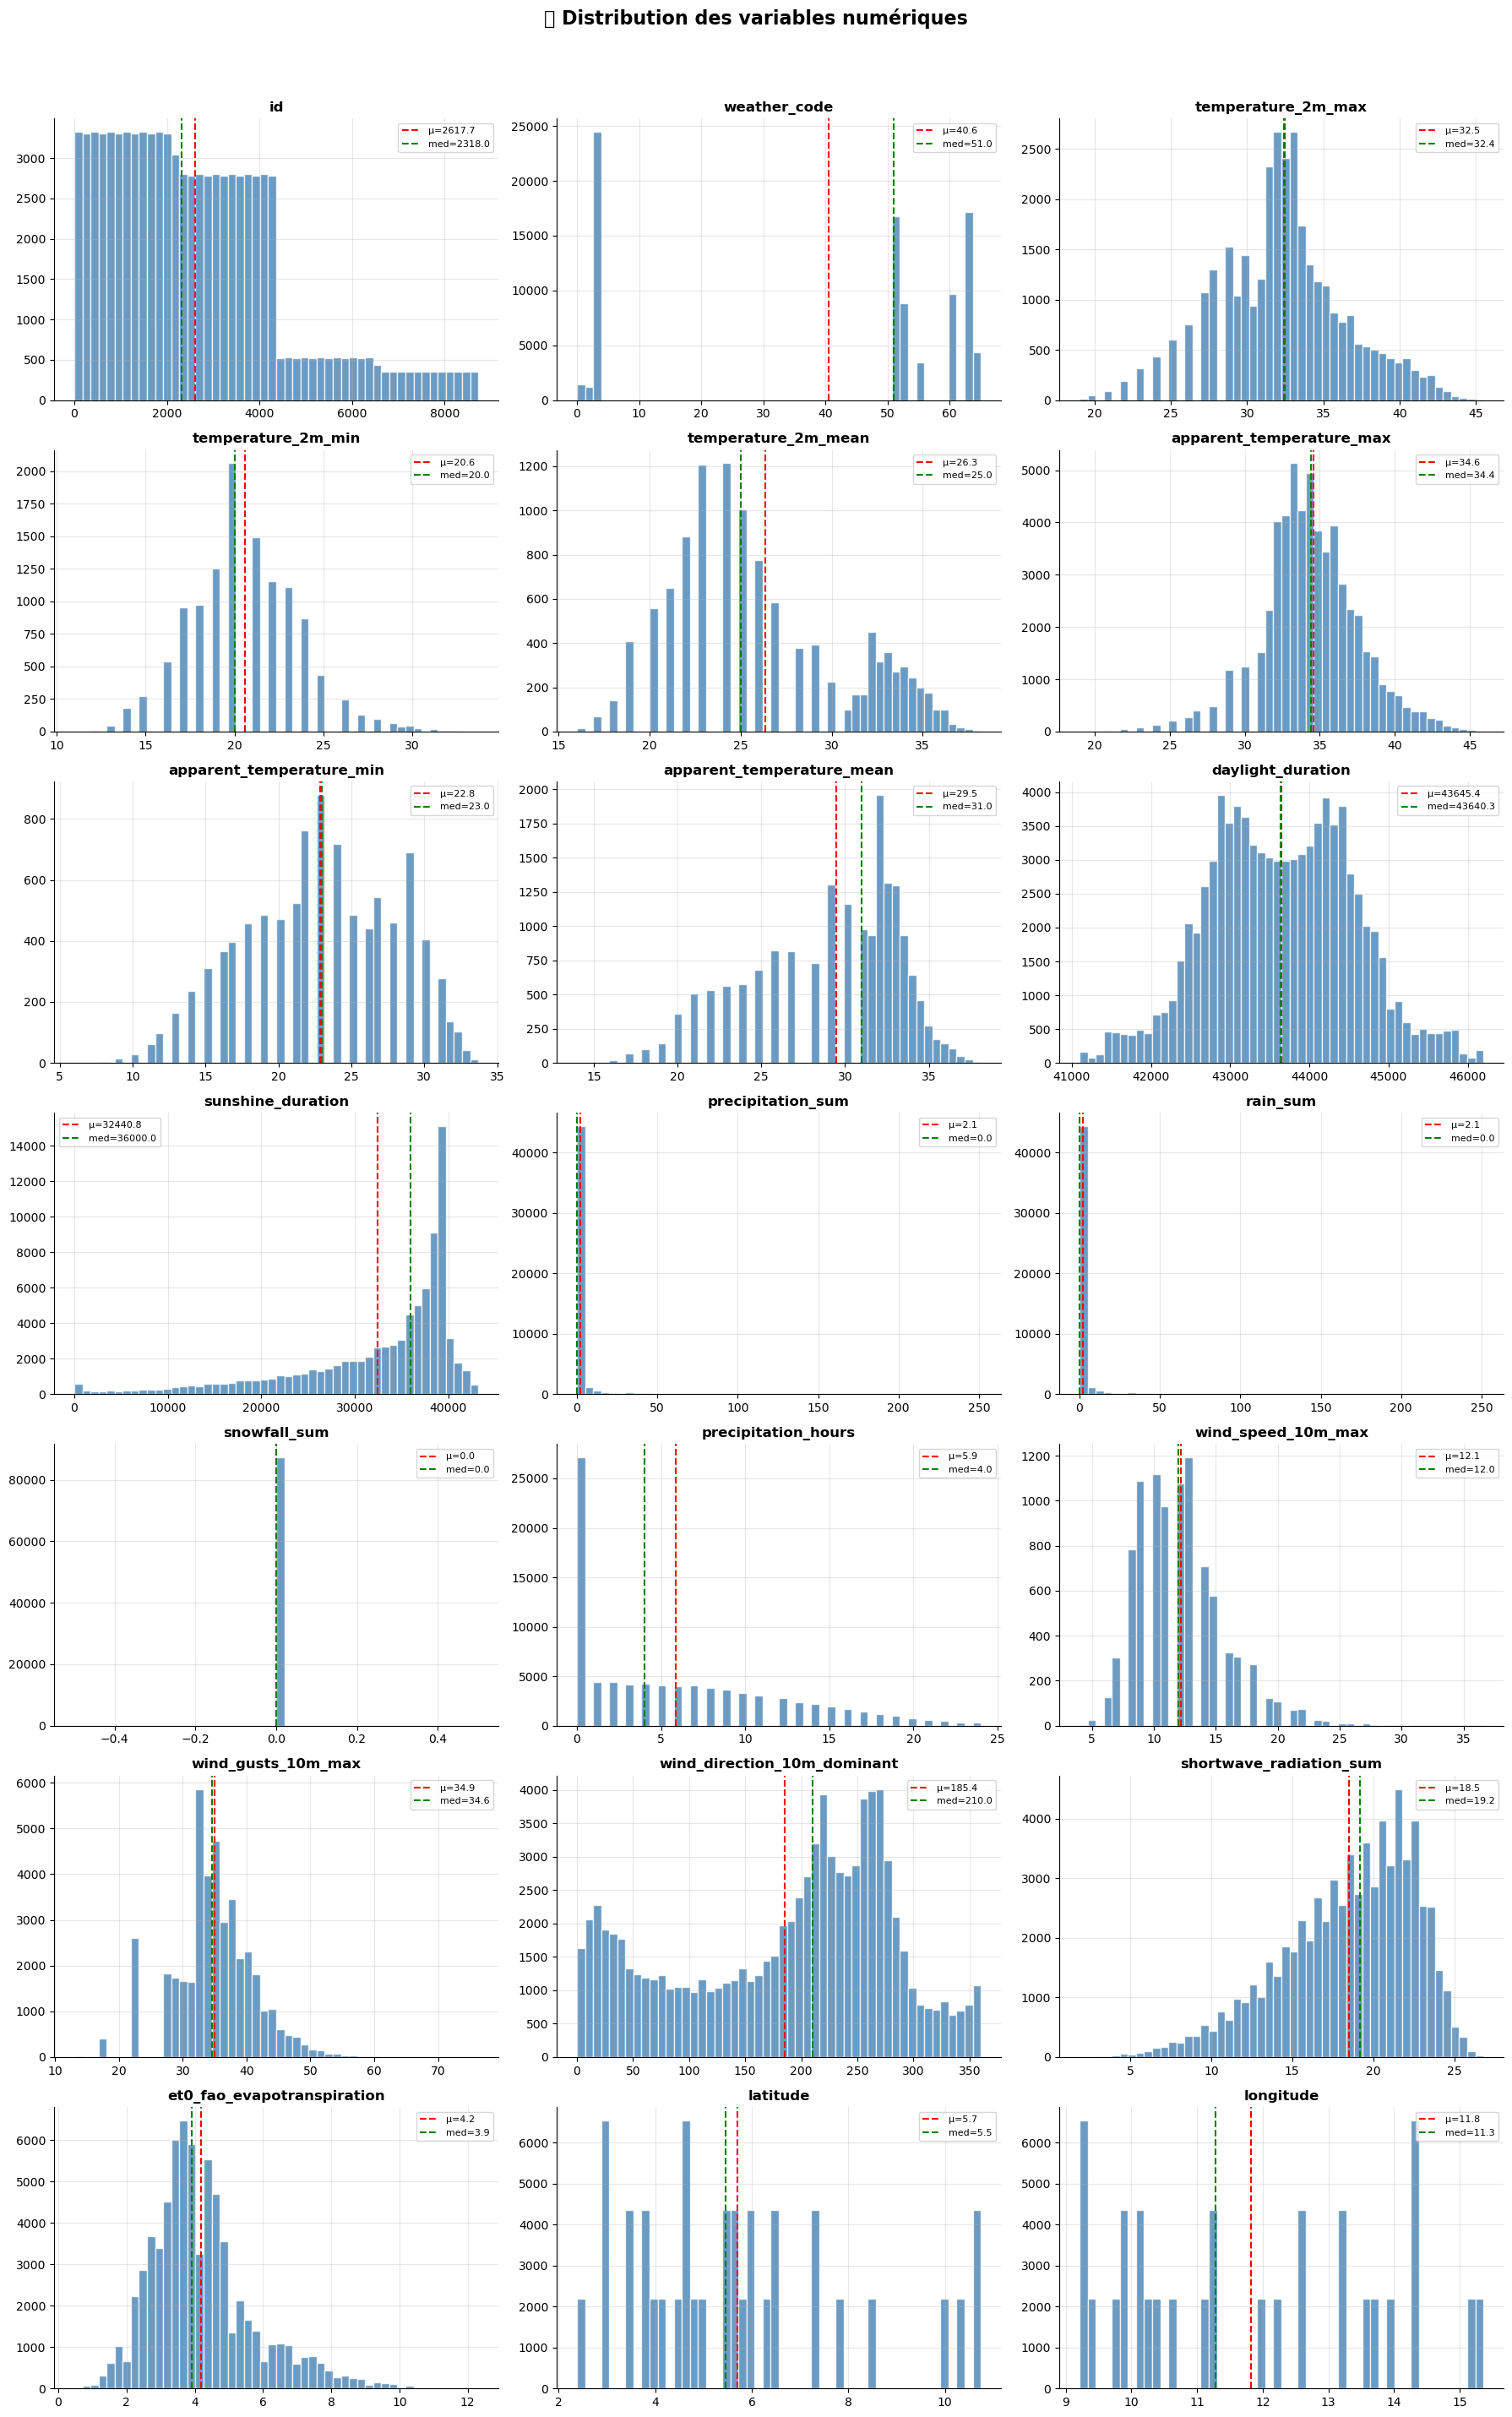

In [71]:
# ── Distribution visuelle ──
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'μ={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'med={df[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("📊 Distribution des variables numériques", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches='tight')
plt.show()